In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
# reding the given csv file into pandas dataframe
trader_df =pd.read_csv('../data/historical_data.csv')
sentiment_df = pd.read_csv('../data/fear_greed_index.csv')

In [6]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
trader_df.shape

(211224, 16)

In [9]:
sentiment_df.shape

(2644, 4)

In [10]:
trader_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [11]:
sentiment_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [12]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [14]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [16]:
trader_df.isnull().sum()


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [17]:
sentiment_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [20]:
trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [22]:
sentiment_df['date']=pd.to_datetime(sentiment_df['date'])

In [23]:
trader_df['date']=trader_df['Timestamp IST'].dt.date

In [24]:
sentiment_df['date']= sentiment_df['date'].dt.date

In [25]:
trader_df.duplicated().sum()    

np.int64(0)

In [26]:
sentiment_df.duplicated().sum()

np.int64(0)

In [27]:
sentiment_df['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [31]:
merged_df=pd.merge(
    trader_df,
    sentiment_df,
    on='date',
    how='left'
)

In [ ]:
# for behavioral analysis 
merged_df[['Coin','Closed PnL', 'classification']].head()

,Coin,Closed PnL,classification
0,@107,0.0,Extreme Greed
1,@107,0.0,Extreme Greed
2,@107,0.0,Extreme Greed
3,@107,0.0,Extreme Greed
4,@107,0.0,Extreme Greed


In [ ]:
# for profitability analysis
profit_df = merged_df[
    merged_df['Closed PnL'] != 0
]

In [35]:
merged_df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

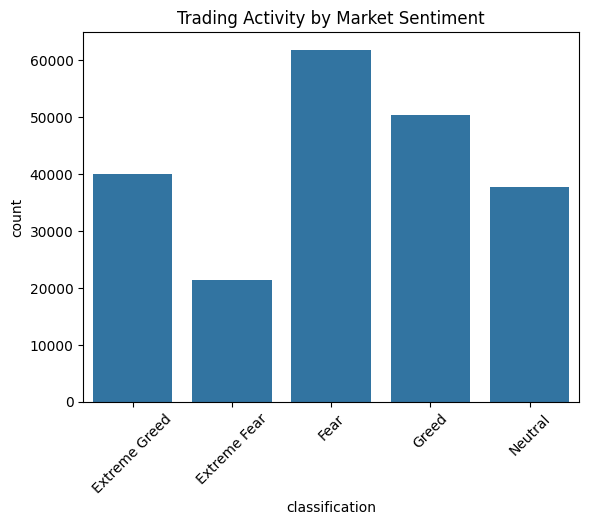

In [36]:
sns.countplot(
    data=merged_df,
    x='classification'
)

plt.xticks(rotation=45)
plt.title("Trading Activity by Market Sentiment")

plt.show()

In [37]:
profit_df.groupby(
    'classification'
)['Closed PnL'].mean()

classification
Extreme Fear      71.027316
Extreme Greed    130.205309
Fear             112.625988
Greed             85.403927
Neutral           71.199993
Name: Closed PnL, dtype: float64

In [38]:
profit_df.groupby(
    'classification'
)['Closed PnL'].median()

classification
Extreme Fear     6.388050
Extreme Greed    8.530740
Fear             6.350483
Greed            4.927600
Neutral          4.583458
Name: Closed PnL, dtype: float64

In [39]:
profit_df.groupby(
    'classification'
)['Closed PnL'].std()

classification
Extreme Fear     1628.408341
Extreme Greed    1058.126139
Fear             1344.778427
Greed            1576.394764
Neutral           743.212863
Name: Closed PnL, dtype: float64

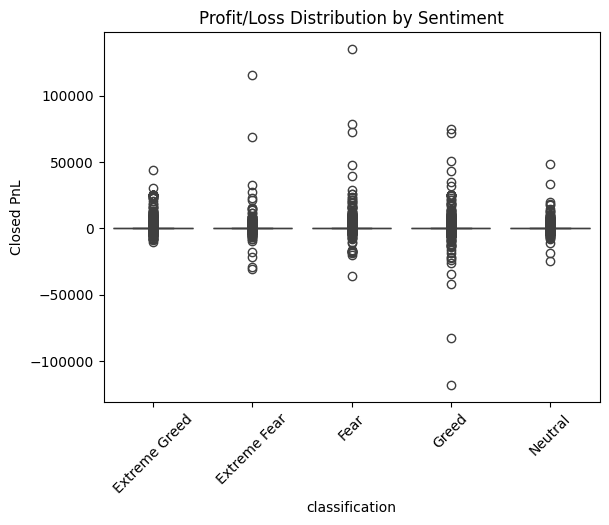

In [40]:
sns.boxplot(
    data=profit_df,
    x='classification',
    y='Closed PnL'
)

plt.xticks(rotation=45)

plt.title("Profit/Loss Distribution by Sentiment")

plt.show()